In [6]:
#importing libraries

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

In [7]:
#Dataset

dataset_path = r"E:\Laptop\Final_project\Data\PlantVillage"

In [8]:
#Number of Classes

classes = os.listdir(dataset_path)

print("Number of Classes:", len(classes))

Number of Classes: 15


In [ ]:
#List of Classes

for cls in sorted(classes):
    print(cls)

Pepper__bell___Bacterial_spot
Pepper__bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Tomato_Bacterial_spot
Tomato_Early_blight
Tomato_Late_blight
Tomato_Leaf_Mold
Tomato_Septoria_leaf_spot
Tomato_Spider_mites_Two_spotted_spider_mite
Tomato__Target_Spot
Tomato__Tomato_YellowLeaf__Curl_Virus
Tomato__Tomato_mosaic_virus
Tomato_healthy


In [ ]:
#Class distribution

class_counts = {}

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    class_counts[cls] = len(os.listdir(cls_path))

df = pd.DataFrame(
    class_counts.items(),
    columns=["Class", "Count"]
)

df.head()

,Class,Count
0,Pepper__bell___Bacterial_spot,997
1,Pepper__bell___healthy,1478
2,Potato___Early_blight,1000
3,Potato___healthy,152
4,Potato___Late_blight,1000


In [23]:
df.sort_values("Count", ascending=False)

,Class,Count
14,Tomato__Tomato_YellowLeaf__Curl_Virus,3209
5,Tomato_Bacterial_spot,2127
8,Tomato_Late_blight,1909
10,Tomato_Septoria_leaf_spot,1771
11,Tomato_Spider_mites_Two_spotted_spider_mite,1676
7,Tomato_healthy,1591
1,Pepper__bell___healthy,1478
12,Tomato__Target_Spot,1404
2,Potato___Early_blight,1000
4,Potato___Late_blight,1000


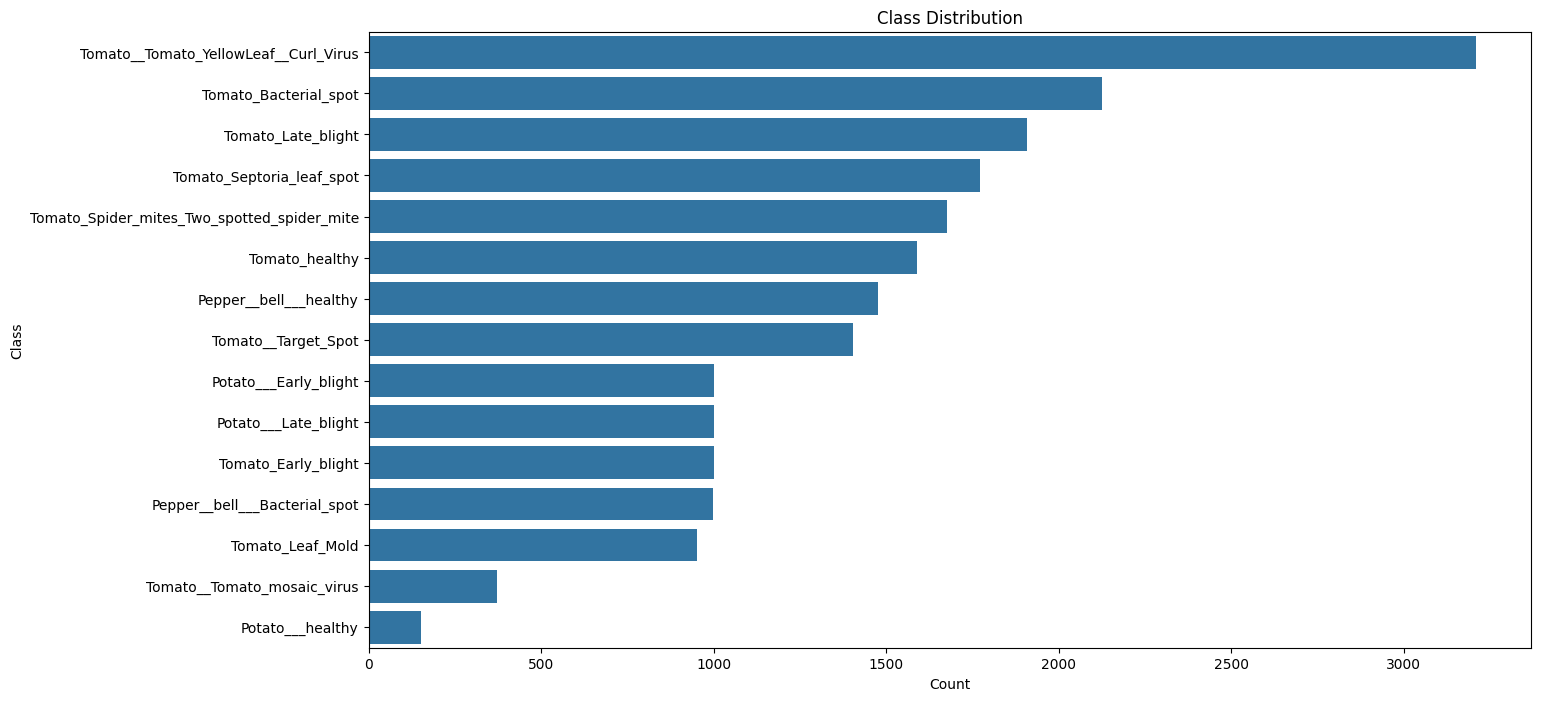

In [ ]:
#Leaf disease distribution

plt.figure(figsize=(15,8))

sns.barplot(
    x="Count",
    y="Class",
    data=df.sort_values(
        by="Count",
        ascending=False
    )
)

plt.title("Class Distribution")
plt.show()

In [17]:
#Checking image size

sizes = []

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)

    img_name = os.listdir(cls_path)[0]

    img_path = os.path.join(
        cls_path,
        img_name
    )

    img = Image.open(img_path)

    sizes.append(img.size)

sizes[:10]

[(256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256)]

In [18]:
#unique sizes

set(sizes)

{(256, 256)}

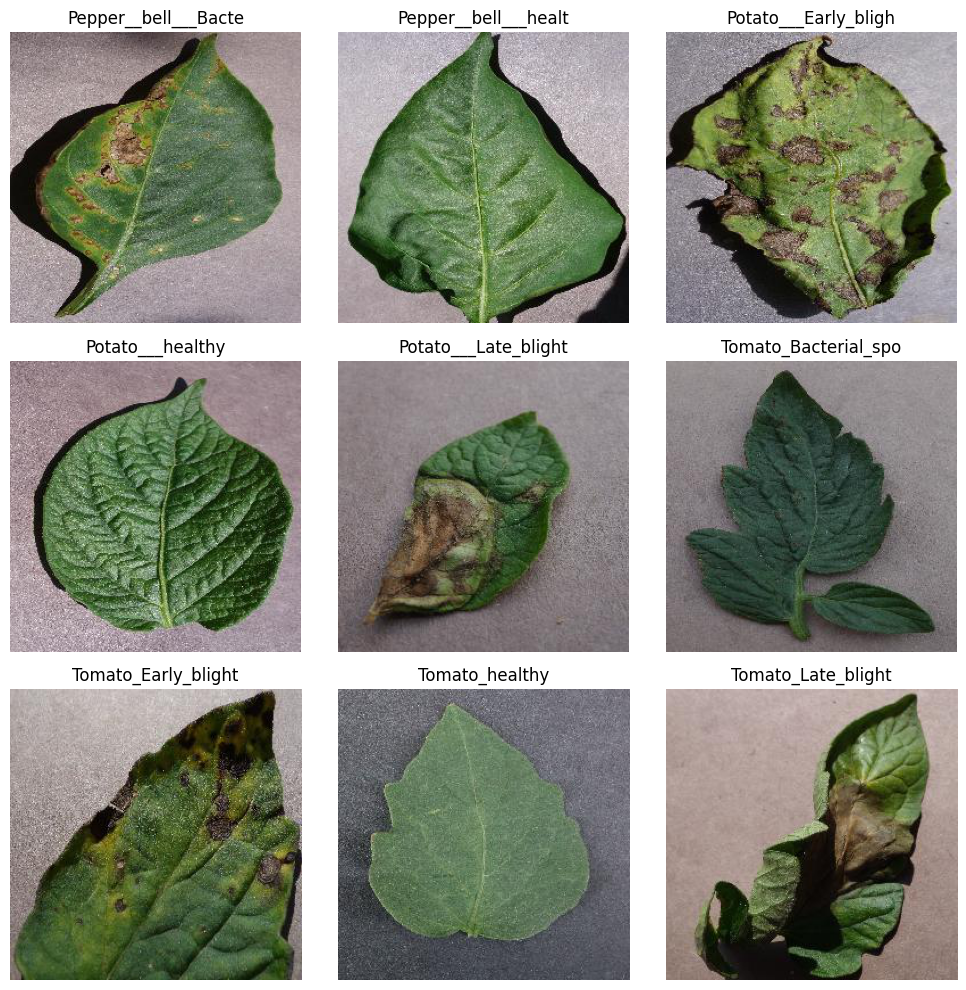

In [21]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(10,10)
)

for ax, cls in zip(
    axes.flatten(),
    classes[:9]
):
    img_path = os.path.join(
        dataset_path,
        cls,
        os.listdir(
            os.path.join(dataset_path, cls)
        )[0]
    )

    img = Image.open(img_path)

    ax.imshow(img)
    ax.set_title(cls[:20])
    ax.axis("off")

plt.tight_layout()
plt.show()